Requirements: **numpy**, **matplotlib**, **h5py**, **datetime**, (scipy, pandas, ...)

I assume you know how to install these packages if you do not have them already. In anaconda they should be already installed by default. In python you simply do 


```
pip3 install h5py datetime numpy matplotlib
```

Let's begin with finding where our files are located

In [25]:
import numpy as np
import pylab as plt
import h5py
from glob import glob
from datetime import datetime,timedelta
from efdpy.utils import *
data_folder = 'C:\\Users\\darmo\\PowerFolders\\IAPS-INAF\\data\\CSES01\\Trento2024\\'

files = glob(data_folder+'*.h5')


We can parse our filename to get some useful info: we do it with a special parsing function `parse_CSES_filename`

In [7]:
CSES_DATA_TABLE = {'EFD':{'1':'ULF','2':'ELF','3':'VLF','4':'HF'},\
                   'HPM':{'1':'FGM1','2':'FGM2','3':'CDSM','5':'FGM1Hz'},\
                   'SCM':{'1':'ULF','2':'ELF','3':'VLF'},\
                   'LAP':{'1':'50mm', '2':'10mm'},\
                   'PAP':{'0':''}, \
                   'HEP':{'1':'P_L','2':'P_H','3':'D','4':'P_X'}}



def parse_CSES_filename(filename):

    fl_list = filename.split('_')
    out={}
    if len(filename) == 66:
        out['Satellite'] = fl_list[0]+fl_list[1]
        out['Instrument'] = fl_list[2]
        try:
            out['Data Product'] = CSES_DATA_TABLE[fl_list[2]][fl_list[3]]
        except:
            out['Data Product'] = 'Unknown' 
        out['Instrument No.'] = fl_list[3]
        out['Data Level'] = fl_list[4]
        out['orbitn'] = fl_list[6]
        out['year'] = fl_list[7][0:4]
        out['month'] = fl_list[7][4:6]
        out['day'] = fl_list[7][6:8]
        out['time'] = fl_list[8][0:2]+':'+fl_list[8][2:4]+':'+fl_list[8][4:6]
        out['t_start'] = datetime(int( out['year']),int(out['month']),int(out['day']),\
                            int(fl_list[8][0:2]),int(fl_list[8][2:4]),int(fl_list[8][4:6])) 
        out['t_end'] = datetime(int(fl_list[9][0:4]),int(fl_list[9][4:6]),int(fl_list[9][6:8]),\
                            int(fl_list[10][0:2]),int(fl_list[10][2:4]),int(fl_list[10][4:6]))
    elif len(filename) == 69:
        out['Satellite'] = fl_list[0]+'_01'
        out['Instrument'] = fl_list[1]
        out['Data Product'] = fl_list[2]
        out['Data Level'] = fl_list[-2]
        out['orbitn'] = fl_list[3]
        out['year'] = fl_list[4][0:4]
        out['month'] = fl_list[4][4:6]
        out['day'] = fl_list[4][6:8]
        out['time'] = fl_list[5][0:2]+':'+fl_list[5][2:4]+':'+fl_list[5][4:6]
        out['t_start'] = datetime(int( out['year']),int(out['month']),int(out['day']),\
                            int(fl_list[5][0:2]),int(fl_list[5][2:4]),int(fl_list[5][4:6])) 
        out['t_end'] = datetime(int(fl_list[6][0:4]),int(fl_list[6][4:6]),int(fl_list[6][6:8]),\
                            int(fl_list[7][0:2]),int(fl_list[7][2:4]),int(fl_list[7][4:6]))

    return out

We now take one file and see the information we can get from its file name

In [8]:
ifile = files[0]
strfile = ifile.split('\\')[-1]

file_info = parse_CSES_filename(strfile)
file_info

{'Satellite': 'CSES01',
 'Instrument': 'EFD',
 'Data Product': 'ULF',
 'Instrument No.': '1',
 'Data Level': 'L02',
 'orbitn': '104240',
 'year': '2019',
 'month': '12',
 'day': '19',
 'time': '23:53:48',
 't_start': datetime.datetime(2019, 12, 19, 23, 53, 48),
 't_end': datetime.datetime(2019, 12, 20, 0, 28, 32)}

Now we look how the file is made. It is an HDF5 file format. So we need the **h5py** package, that we already imported.

In [9]:
fil = h5py.File(ifile,'r')

fil.keys()

fil['A111_W'].shape

(1001, 256)

It does not look like a timeseries, is a 2D array. Why? The reason is that EFD waveforms (also SCM) are subdivided in packets (256 in ULF, 2048 in ELF). The timeseries is actually the flattened array.

In [10]:
plt.plot(fil['A111_W'].flatten())

AttributeError: 'Dataset' object has no attribute 'flatten'

We got an error because fil['A111_W'] is not exactly our array, but is the hdf5 dataset containing the array. To plot it we need to add ```[...]``` to the syntax: 

In [11]:
fil['A111_W']

<HDF5 dataset "A111_W": shape (1001, 256), type "<f8">

In [13]:
fil['A111_W'][...]

array([[-137.26848364, -137.27663457, -137.28363812, ..., -138.93908262,
        -138.94660771, -138.94921541],
       [-138.62083852, -138.61772418, -138.61355186, ..., -139.62237537,
        -139.6253109 , -139.63018358],
       [-139.30742443, -139.31277394, -139.31551576, ..., -138.80597055,
        -138.79369199, -138.78023624],
       ...,
       [ 213.61015737,  213.61188591,  213.61157298, ...,  213.53189647,
         213.53207529,  213.53195608],
       [ 213.33274245,  213.33289146,  213.33219111, ...,  213.05440366,
         213.05152774,  213.05021644],
       [ 212.84717321,  212.84791827,  212.8482759 , ...,  213.28157187,
         213.28170598,  213.28108013]])

In [ ]:
fil['A111_W'][...].flatten()


(256256,)

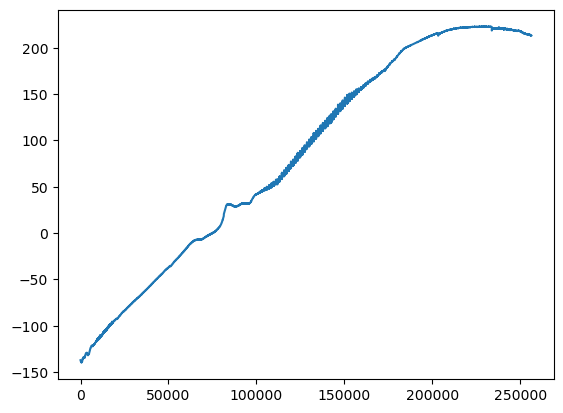

In [16]:
fil['A111_W'][...].flatten().shape

plt.plot(fil['A111_W'][...].flatten())


Now we need to add the information about time and what goes on the y-axis. Fortunately, the hdf5 format allows to also insert metadata infos about what is in the data (granted that someone put that information). We can see the information about the field 'A111_W' with the following command

In [ ]:
fil['A111_W'].attrs['units']

array([b'mV/m'], dtype='|S5')

The information tells us that this dataset is in units of mV/m, i.e. $10^-3$ V/m.
The array containing the time information is TIME_VERSE, and it gives the time of the first datapoint of each packet. Since our field 'A111_W' is subdivided in (1001,256), TIME_VERSE will be a 1D array of 1001 elements, each of them gives the time of, e.g., fil['A111_W'][:,0].

VERSE_TIME is given in milliseconds, and is the time since midnight of january 1, 2009. We can convert such number to a more useful format by using `datetime`. We now show a way to do it.

In [20]:
verse_time0 = datetime(2009,1,1) #UTC time offset of verse time

vtime = fil['VERSE_TIME'][...].flatten() #getting a flattened array of VERSE_TIMES in milliseconds

utime = verse_time0 + vtime*timedelta(milliseconds=1)


This is the plot with VERSE_TIME in milliseconds on the x-axis

Text(0, 0.5, 'mV/m')

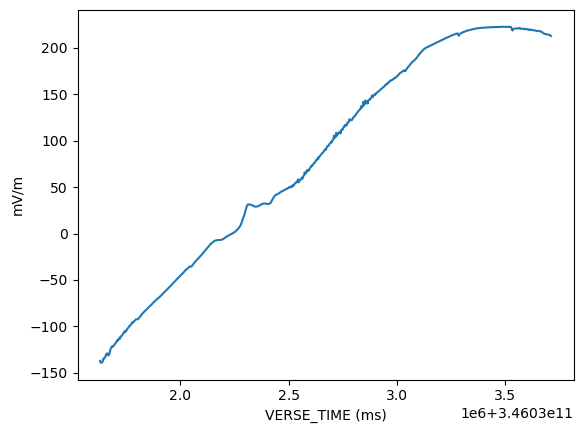

In [17]:
plt.plot(fil['VERSE_TIME'][...],fil['A111_W'][:,0])
plt.xlabel('VERSE_TIME (ms)')
plt.ylabel('mV/m')

In [18]:
plt.plot(utime,fil['A111_W'][:,0])
plt.xlabel('UT time')
plt.ylabel('mV/m')

NameError: name 'utime' is not defined

## Problem 1
Build a time array (can be datetime array or numpy array in seconds or whatever) of the same size of 'A111_W' so that we have the temporal position of each datapoint. 

**Question 1**: How would you do it?

In [21]:
dt = 1/125 #ULF sampling time

#using vtime
vtimefull = np.zeros(fil['A111_W'].shape)
packetsize = vtimefull.shape[1]
for i,itime in enumerate(vtime):
    vtimefull[i] = np.arange(packetsize)*dt + itime


#using datetime
utimefull = [i+dt*timedelta(seconds=1)*np.arange(packetsize) for i in utime]

utimefull = np.array(utimefull)

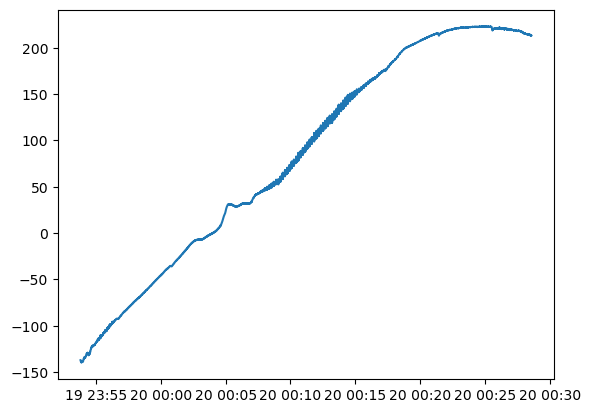

In [22]:
plt.plot(utimefull.flatten(),fil['A111_W'][...].flatten())

There is another issue related to timing: VERSE_TIME is an integer in milliseconds. This bring some issues in the discretization of timing, as can be easily seen here.

**Question 2**: How would you solve it? Is it so terrible to keep this error?


In [23]:
np.diff(vtime)

array([2048, 2047, 6138, 2047, 2049, 2048, 2047, 2049, 2047, 2048, 2049,
       2047, 2049, 2048, 2047, 2049, 2047, 2048, 2049, 2047, 2049, 2048,
       2047, 2049, 2048, 2047, 2049, 2047, 2048, 2049, 2047, 2049, 2048,
       2047, 2049, 2047, 2048, 2049, 2047, 2048, 2049, 2047, 2049, 2048,
       2047, 2049, 2047, 2048, 2049, 2047, 2049, 2048, 2047, 2049, 2047,
       2048, 2049, 2047, 2048, 2049, 2047, 2049, 2048, 2047, 2049, 2047,
       2048, 2049, 2047, 2049, 2048, 2047, 2049, 2047, 2048, 2049, 2047,
       2048, 2049, 6124, 2048, 2047, 2049, 2047, 2048, 2049, 2047, 2049,
       2048, 2047, 2049, 2047, 2048, 2049, 2047, 2049, 2048, 2047, 2049,
       2048, 2047, 2049, 2047, 2048, 2049, 2047, 2049, 2048, 2047, 2049,
       2047, 2048, 2049, 2047, 2049, 2048, 2047, 2049, 2048, 2047, 2049,
       2047, 2048, 2049, 2047, 2049, 2048, 2047, 2049, 2047, 2048, 2049,
       2047, 2049, 2048, 2047, 2049, 2048, 2047, 2049, 2047, 2048, 2049,
       2047, 2049, 2048, 2047, 2049, 2047, 2048, 20

While solving the issue related to the presence of this "bug", you have to keep in mind that gaps are present in the data:


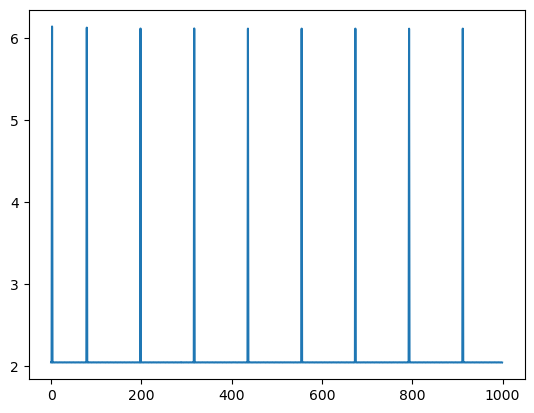

In [24]:
plt.plot(np.diff(vtime)/1000)

The data contains gaps of length 6.138 seconds. Why is that? 

The reason is that there are some telemetry packets that are lost. (It is an EFD issue to be aware of).

This gaps are not randomly distributed, so it seems it is something systematic happening to EFD

How do we see that this is an issue?  [do it interactively with the following commands]

```
plt.ion()
plt.plot(utimefull.flatten(),fil['A111_W'][...].flatten(),'.')
plt.show()
```